In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve
)
import joblib

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
%matplotlib inline

In [2]:
import sys
from pathlib import Path
sys.path.append(str(Path('..').resolve()))
from app.feature_engineering import CGMFeatureEngineer


In [3]:
train_df = pd.read_csv('../data/processed/train_data.csv')
fe = CGMFeatureEngineer(spike_threshold=180.0, prediction_horizon_minutes=120)
features_df = fe.create_features(train_df)


/var/folders/3p/4rqnf9yd027770h9vdcqrrhw0000gn/T/ipykernel_27617/145379850.py:1: DtypeWarning: Columns (17) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df = pd.read_csv('../data/processed/train_data.csv')


Creating features...
  Processing patient 559...
  Processing patient 563...
  Processing patient 570...
  Processing patient 575...
  Processing patient 588...
  Processing patient 591...
Created 78 features for 69255 samples


In [4]:
features_df.columns

Index(['patient_id', 'timestamp', 'glucose', 'meal_timestamp', 'meal_type',
       'carbs', 'finger_stick_timestamp', 'finger_stick_glucose', 'basal_rate',
       'temp_basal_rate', 'bolus_timestamp', 'bolus_dose',
       'exercise_timestamp', 'exercise_duration', 'exercise_intensity',
       'hypo_timestamp', 'hypo_event', 'stress_timestamp', 'stress_event',
       'heart_rate', 'gsr', 'skin_temp_f', 'air_temp_f', 'steps',
       'glucose_delta_5min', 'glucose_delta_15min', 'glucose_delta_30min',
       'glucose_delta_60min', 'glucose_delta_120min', 'glucose_velocity_5min',
       'glucose_velocity_15min', 'glucose_velocity_30min',
       'glucose_velocity_60min', 'glucose_accel_15min', 'glucose_accel_30min',
       'glucose_rising', 'glucose_falling', 'glucose_stable',
       'glucose_rising_fast', 'glucose_std_30min', 'glucose_std_60min',
       'glucose_range_30min', 'glucose_range_60min', 'glucose_mean_60min',
       'glucose_mean_120min', 'hour', 'day_of_week', 'is_morning',
    

In [5]:
# # Load the engineered features
# features_df = pd.read_csv('../data/processed/train_features.csv', parse_dates=['timestamp'])

# print(f"Loaded features: {features_df.shape}")
# print(f"Columns: {len(features_df.columns)}")
# features_df.head()

In [6]:
features_df.columns

Index(['patient_id', 'timestamp', 'glucose', 'meal_timestamp', 'meal_type',
       'carbs', 'finger_stick_timestamp', 'finger_stick_glucose', 'basal_rate',
       'temp_basal_rate', 'bolus_timestamp', 'bolus_dose',
       'exercise_timestamp', 'exercise_duration', 'exercise_intensity',
       'hypo_timestamp', 'hypo_event', 'stress_timestamp', 'stress_event',
       'heart_rate', 'gsr', 'skin_temp_f', 'air_temp_f', 'steps',
       'glucose_delta_5min', 'glucose_delta_15min', 'glucose_delta_30min',
       'glucose_delta_60min', 'glucose_delta_120min', 'glucose_velocity_5min',
       'glucose_velocity_15min', 'glucose_velocity_30min',
       'glucose_velocity_60min', 'glucose_accel_15min', 'glucose_accel_30min',
       'glucose_rising', 'glucose_falling', 'glucose_stable',
       'glucose_rising_fast', 'glucose_std_30min', 'glucose_std_60min',
       'glucose_range_30min', 'glucose_range_60min', 'glucose_mean_60min',
       'glucose_mean_120min', 'hour', 'day_of_week', 'is_morning',
    

In [7]:
len(features_df.columns)

78

In [8]:
# Columns to exclude from features
exclude_cols = [
    'patient_id', 'timestamp', 'will_spike', 'future_glucose_max',
    'carbs', 'bolus_dose', 'meal_type',
    'exercise_duration', 'exercise_intensity','finger_stick_glucose','glucose_baseline',
       'future_glucose_rise',
    # Exclude all timestamp columns
    'meal_timestamp', 'finger_stick_timestamp', 'bolus_timestamp',
    'exercise_timestamp', 'hypo_timestamp', 'stress_timestamp'
]

# Get feature columns
feature_cols = [col for col in features_df.columns if col not in exclude_cols]

# Create X (features) and y (target)
X_full = features_df[feature_cols].copy()
y_full = features_df['will_spike'].copy()

# Fill any remaining NaN with 0
X_full = X_full.fillna(0)

# Drop rows with NaN in target
valid_idx = ~y_full.isna()
X_full = X_full[valid_idx]
y_full = y_full[valid_idx]

print(f"\nPrepared dataset:")
print(f"  Features (X): {X_full.shape}")
print(f"  Target (y): {y_full.shape}")
print(f"  Feature columns: {len(feature_cols)}")
print(f"\nTarget distribution:")
print(f"  No spike (0): {(y_full == 0).sum():,} ({(y_full == 0).sum() / len(y_full) * 100:.1f}%)")
print(f"  Will spike (1): {(y_full == 1).sum():,} ({(y_full == 1).sum() / len(y_full) * 100:.1f}%)")


Prepared dataset:
  Features (X): (69255, 60)
  Target (y): (69255,)
  Feature columns: 60

Target distribution:
  No spike (0): 32,982 (47.6%)
  Will spike (1): 36,273 (52.4%)


In [9]:
X_full.columns

Index(['glucose', 'basal_rate', 'temp_basal_rate', 'hypo_event',
       'stress_event', 'heart_rate', 'gsr', 'skin_temp_f', 'air_temp_f',
       'steps', 'glucose_delta_5min', 'glucose_delta_15min',
       'glucose_delta_30min', 'glucose_delta_60min', 'glucose_delta_120min',
       'glucose_velocity_5min', 'glucose_velocity_15min',
       'glucose_velocity_30min', 'glucose_velocity_60min',
       'glucose_accel_15min', 'glucose_accel_30min', 'glucose_rising',
       'glucose_falling', 'glucose_stable', 'glucose_rising_fast',
       'glucose_std_30min', 'glucose_std_60min', 'glucose_range_30min',
       'glucose_range_60min', 'glucose_mean_60min', 'glucose_mean_120min',
       'hour', 'day_of_week', 'is_morning', 'is_afternoon', 'is_evening',
       'is_night', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos',
       'minutes_since_meal', 'carbs_from_last_meal', 'had_meal_recently',
       'had_meal_very_recently', 'carbs_last_30min', 'carbs_last_60min',
       'carbs_last_120min', 'high_ca

In [10]:
y_full.value_counts()

will_spike
1    36273
0    32982
Name: count, dtype: int64

In [11]:


# Split into train+val (80%) and test (20%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_full, y_full, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_full
)

# Split train+val into train (75% of 80% = 60%) and val (25% of 80% = 20%)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.25,  # 25% of 80% = 20% of total
    random_state=42,
    stratify=y_train_val
)

print(f"\nData splits:")
print(f"  Training:   {len(X_train):,} samples ({len(X_train)/len(X_full)*100:.1f}%)")
print(f"  Validation: {len(X_val):,} samples ({len(X_val)/len(X_full)*100:.1f}%)")
print(f"  Test:       {len(X_test):,} samples ({len(X_test)/len(X_full)*100:.1f}%)")

print(f"\nTarget distribution - Training:")
print(f"  No spike: {(y_train == 0).sum():,} ({(y_train == 0).sum() / len(y_train) * 100:.1f}%)")
print(f"  Will spike: {(y_train == 1).sum():,} ({(y_train == 1).sum() / len(y_train) * 100:.1f}%)")


Data splits:
  Training:   41,553 samples (60.0%)
  Validation: 13,851 samples (20.0%)
  Test:       13,851 samples (20.0%)

Target distribution - Training:
  No spike: 19,789 (47.6%)
  Will spike: 21,764 (52.4%)


In [12]:
print("Training Logistic Regression (baseline)...")
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
lr_model.fit(X_train, y_train)
print("✓ Logistic Regression trained")

Training Logistic Regression (baseline)...
✓ Logistic Regression trained


/Users/adda247/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [13]:
print("Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
print("✓ Random Forest trained")

Training Random Forest...
✓ Random Forest trained


In [14]:
print("Training Gradient Boosting...")
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)
gb_model.fit(X_train, y_train)
print("✓ Gradient Boosting trained")

Training Gradient Boosting...
✓ Gradient Boosting trained


In [15]:
models = {
    'Logistic Regression': lr_model,
    'Random Forest': rf_model,
    'Gradient Boosting': gb_model
}

results = {}

for name, model in models.items():
    print(f"\n{'='*60}")
    print(f"{name.upper()}")
    print(f"{'='*60}")
    
    # Validation predictions
    y_val_pred = model.predict(X_val)
    y_val_proba = model.predict_proba(X_val)[:, 1]
    
    val_roc_auc = roc_auc_score(y_val, y_val_proba)
    val_pr_auc = average_precision_score(y_val, y_val_proba)
    
    print(f"\nValidation Performance:")
    print(f"  ROC-AUC: {val_roc_auc:.4f}")
    print(f"  PR-AUC:  {val_pr_auc:.4f}")
    print(f"\nClassification Report (Validation):")
    print(classification_report(y_val, y_val_pred, target_names=['No Spike', 'Will Spike']))
    
    # Test predictions
    y_test_pred = model.predict(X_test)
    y_test_proba = model.predict_proba(X_test)[:, 1]
    
    test_roc_auc = roc_auc_score(y_test, y_test_proba)
    test_pr_auc = average_precision_score(y_test, y_test_proba)
    
    print(f"\nTest Performance:")
    print(f"  ROC-AUC: {test_roc_auc:.4f}")
    print(f"  PR-AUC:  {test_pr_auc:.4f}")
    print(f"\nClassification Report (Test):")
    print(classification_report(y_test, y_test_pred, target_names=['No Spike', 'Will Spike']))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_test_pred)
    print(f"\nConfusion Matrix (Test):")
    print(cm)
    print(f"  [[TN={cm[0,0]}, FP={cm[0,1]}]")
    print(f"   [FN={cm[1,0]}, TP={cm[1,1]}]]")
    
    # Store results
    results[name] = {
        'model': model,
        'val_roc_auc': val_roc_auc,
        'val_pr_auc': val_pr_auc,
        'test_roc_auc': test_roc_auc,
        'test_pr_auc': test_pr_auc,
        'y_test_pred': y_test_pred,
        'y_test_proba': y_test_proba
    }


LOGISTIC REGRESSION

Validation Performance:
  ROC-AUC: 0.8936
  PR-AUC:  0.9242

Classification Report (Validation):
              precision    recall  f1-score   support

    No Spike       0.80      0.84      0.82      6597
  Will Spike       0.85      0.80      0.83      7254

    accuracy                           0.82     13851
   macro avg       0.82      0.82      0.82     13851
weighted avg       0.82      0.82      0.82     13851


Test Performance:
  ROC-AUC: 0.8980
  PR-AUC:  0.9279

Classification Report (Test):
              precision    recall  f1-score   support

    No Spike       0.80      0.83      0.82      6596
  Will Spike       0.84      0.81      0.83      7255

    accuracy                           0.82     13851
   macro avg       0.82      0.82      0.82     13851
weighted avg       0.82      0.82      0.82     13851


Confusion Matrix (Test):
[[5498 1098]
 [1377 5878]]
  [[TN=5498, FP=1098]
   [FN=1377, TP=5878]]

RANDOM FOREST

Validation Performance:
  R

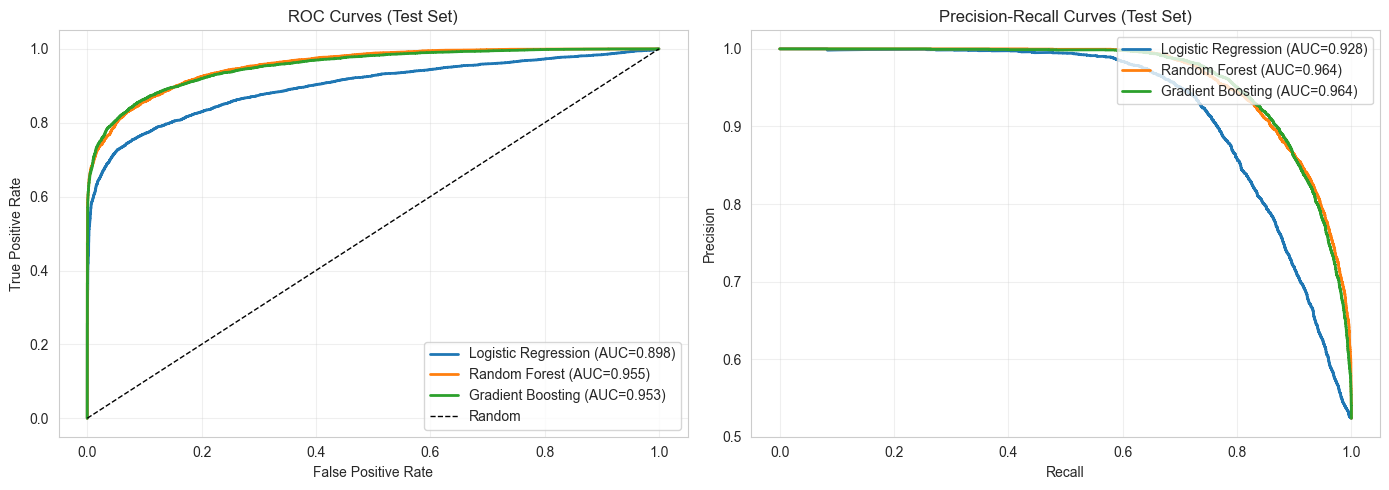

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curves
for name in results.keys():
    fpr, tpr, _ = roc_curve(y_test, results[name]['y_test_proba'])
    auc = results[name]['test_roc_auc']
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', linewidth=2)

axes[0].plot([0, 1], [0, 1], 'k--', label='Random', linewidth=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves (Test Set)')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

# Precision-Recall Curves
for name in results.keys():
    precision, recall, _ = precision_recall_curve(y_test, results[name]['y_test_proba'])
    auc = results[name]['test_pr_auc']
    axes[1].plot(recall, precision, label=f'{name} (AUC={auc:.3f})', linewidth=2)

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves (Test Set)')
axes[1].legend(loc='upper right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


Best model: Random Forest
  Test ROC-AUC: 0.9551
  Test PR-AUC: 0.9643

Top 20 Most Important Features:
               feature  importance
               glucose    0.292381
    glucose_mean_60min    0.197042
   glucose_mean_120min    0.116998
  glucose_delta_120min    0.048261
   glucose_delta_60min    0.036442
glucose_velocity_60min    0.024327
glucose_velocity_30min    0.018509
   glucose_delta_30min    0.014025
 glucose_velocity_5min    0.013999
glucose_velocity_15min    0.013947
    minutes_since_meal    0.012371
  carbs_from_last_meal    0.012120
              hour_cos    0.011369
                   gsr    0.011328
    glucose_delta_5min    0.011310
   glucose_delta_15min    0.011264
       temp_basal_rate    0.010937
     glucose_std_60min    0.010185
            basal_rate    0.010103
                  hour    0.009644


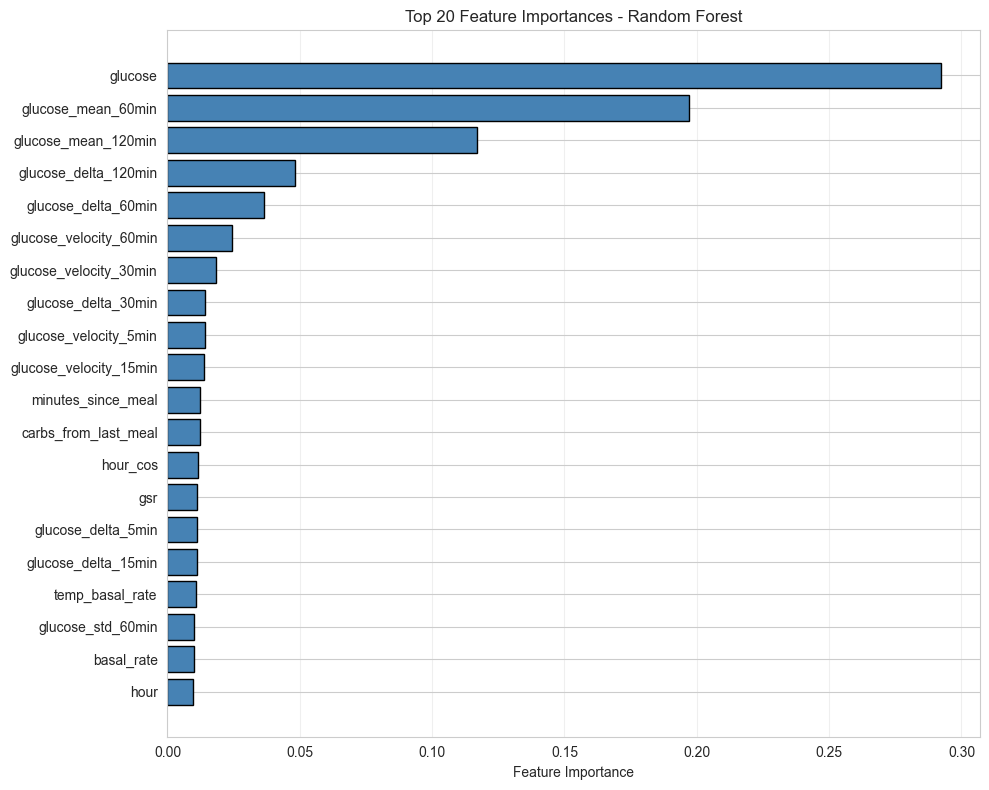

In [17]:
best_model_name = max(results.keys(), key=lambda k: results[k]['test_roc_auc'])
best_model = results[best_model_name]['model']

print(f"\nBest model: {best_model_name}")
print(f"  Test ROC-AUC: {results[best_model_name]['test_roc_auc']:.4f}")
print(f"  Test PR-AUC: {results[best_model_name]['test_pr_auc']:.4f}")

if hasattr(best_model, 'feature_importances_'):
    print(f"\nTop 20 Most Important Features:")
    print("="*60)
    
    importances = pd.DataFrame({
        'feature': feature_cols,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print(importances.head(20).to_string(index=False))
    
    # Visualize feature importance
    top_features = importances.head(20)
    
    plt.figure(figsize=(10, 8))
    plt.barh(range(len(top_features)), top_features['importance'].values, color='steelblue', edgecolor='black')
    plt.yticks(range(len(top_features)), top_features['feature'].values)
    plt.xlabel('Feature Importance')
    plt.title(f'Top 20 Feature Importances - {best_model_name}')
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print(f"\n{best_model_name} does not have feature_importances_")

In [41]:
models_dir = Path("../models")
models_dir.mkdir(exist_ok=True)

best_model_path = models_dir / "spike_predictor.pkl"
joblib.dump(best_model, best_model_path)
print(f"✓ Best model saved: {best_model_path}")

feature_names_path = models_dir / "feature_names.txt"
with open(feature_names_path, 'w') as f:
    f.write('\n'.join(feature_cols))
print(f"✓ Feature names saved: {feature_names_path}")

metadata = {
    'model_type': best_model_name,
    'spike_threshold': 180.0,
    'prediction_horizon_minutes': 120,
    'n_features': len(feature_cols),
    'test_roc_auc': results[best_model_name]['test_roc_auc'],
    'test_pr_auc': results[best_model_name]['test_pr_auc'],
    'training_samples': len(X_train),
    'validation_samples': len(X_val),
    'test_samples': len(X_test)
}

metadata_path = models_dir / "model_metadata.txt"
with open(metadata_path, 'w') as f:
    for key, value in metadata.items():
        f.write(f"{key}: {value}\n")
print(f"✓ Metadata saved: {metadata_path}")

print(f"\n{'='*60}")
print("MODEL TRAINING COMPLETE")
print(f"{'='*60}")
print(f"\nBest model: {best_model_name}")
print(f"Test ROC-AUC: {results[best_model_name]['test_roc_auc']:.4f}")
print(f"Test PR-AUC: {results[best_model_name]['test_pr_auc']:.4f}")
print(f"\nSaved to: {models_dir.absolute()}")

✓ Best model saved: ../models/spike_predictor.pkl
✓ Feature names saved: ../models/feature_names.txt
✓ Metadata saved: ../models/model_metadata.txt

MODEL TRAINING COMPLETE

Best model: Random Forest
Test ROC-AUC: 0.9561
Test PR-AUC: 0.9648

Saved to: /Users/adda247/Desktop/sugarfit/notebook/../models


In [42]:
sample_idx = 100
sample_features = X_test.iloc[sample_idx:sample_idx+1]
sample_target = y_test.iloc[sample_idx]

prediction = best_model.predict(sample_features)[0]
probability = best_model.predict_proba(sample_features)[0, 1]

print(f"\nSample Prediction:")
print(f"  Actual: {'Will Spike' if sample_target == 1 else 'No Spike'}")
print(f"  Predicted: {'Will Spike' if prediction == 1 else 'No Spike'}")
print(f"  Spike Probability: {probability:.2%}")
print(f"\nTop 10 feature values for this sample:")
sample_df = pd.DataFrame({
    'feature': feature_cols,
    'value': sample_features.values[0]
})
print(sample_df.head(10).to_string(index=False))


Sample Prediction:
  Actual: No Spike
  Predicted: No Spike
  Spike Probability: 7.90%

Top 10 feature values for this sample:
        feature     value
        glucose 71.000000
     basal_rate  0.980000
temp_basal_rate  0.980000
     hypo_event  0.000000
   stress_event  0.000000
     heart_rate 80.017100
            gsr  0.000000
    skin_temp_f 87.975048
     air_temp_f 84.660213
          steps  0.000000
